In [1]:
from data.datasets.synthetic.banana_dataset import BananaDataset
from configs.datasets.synthetic.banana_dataset import BananaDatasetConfig

In [2]:
dataset_config = BananaDatasetConfig()
dataset = BananaDataset(config=dataset_config)
splits = dataset.get_splits()

In [3]:
from data.loaders import make_xy_dataloader

In [4]:
train_dataloader = make_xy_dataloader(
    data=splits.train,
    batch_size=256,
    shuffle=True
)

In [5]:
from predictors.transport.flow_matching import FlowMatchingPredictor
from configs.predictors.transport.flow_matching import FlowMatchingPredictorConfig

In [6]:
predictor_config = FlowMatchingPredictorConfig(x_dim=1, y_dim=2)
predictor = FlowMatchingPredictor(config=predictor_config)

In [7]:
from trainers.transport.flow_matching import FlowMatchingTrainer
from configs.trainers.transport.flow_matching import FlowMatchingTrainerConfig

In [8]:
trainer_config = FlowMatchingTrainerConfig()
trainer = FlowMatchingTrainer(config=trainer_config)

In [9]:
_ = trainer.fit(
    predictor=predictor,
    dataloader=train_dataloader
)

Epoch 100 | Loss 1.9011: 100%|██████████| 100/100 [00:05<00:00, 17.95it/s]


FlowMatchingPredictor(
  (vector_field): MLPVectorField(
    (net): Sequential(
      (0): Linear(in_features=4, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): SiLU()
      (4): Linear(in_features=128, out_features=128, bias=True)
      (5): SiLU()
      (6): Linear(in_features=128, out_features=128, bias=True)
      (7): SiLU()
      (8): Linear(in_features=128, out_features=2, bias=True)
    )
  )
  (y_scaler): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=False, bias=False, track_running_stats=True)
)

In [12]:
import torch

number_of_eval_samples = 100
condition = torch.ones([number_of_eval_samples, 1]) * 2
ground_truth = dataset.sample_conditional(x=condition, n_samples=1).squeeze()
samples = predictor.sample(condition, n_samples=1).squeeze()

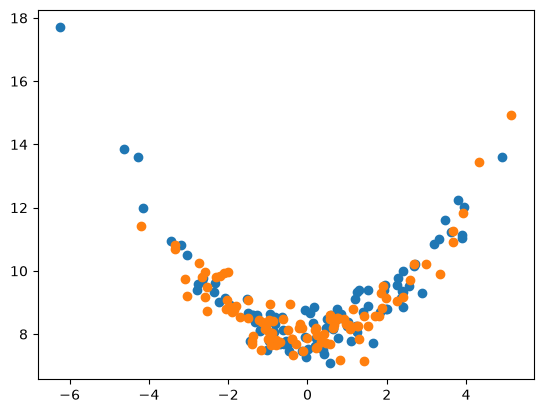

In [13]:
import matplotlib.pyplot as plt

plt.scatter(ground_truth[:, 0], ground_truth[:, 1])
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()

In [15]:
trainer.config

FlowMatchingTrainerConfig(epochs=100, batch_size=256, learning_rate=0.001, weight_decay=0.0001, grad_clip_norm=1.0, use_cosine_scheduler=True, num_workers=0, pin_memory=False, verbose=True)